In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.ensemble import StackingRegressor

from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score

In [87]:
data = pd.read_csv(
    "laptop_price.csv",
    encoding="latin1"
)

In [88]:
print(sorted(data['Company'].unique()))

print(sorted(data['TypeName'].unique()))

print(sorted(data['OpSys'].unique()))

['Acer', 'Apple', 'Asus', 'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei', 'LG', 'Lenovo', 'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba', 'Vero', 'Xiaomi']
['2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook', 'Ultrabook', 'Workstation']
['Android', 'Chrome OS', 'Linux', 'Mac OS X', 'No OS', 'Windows 10', 'Windows 10 S', 'Windows 7', 'macOS']


In [32]:
data.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [33]:
data.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [35]:
data.shape

(1303, 13)

In [36]:
data.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [37]:
data.duplicated().sum()

0

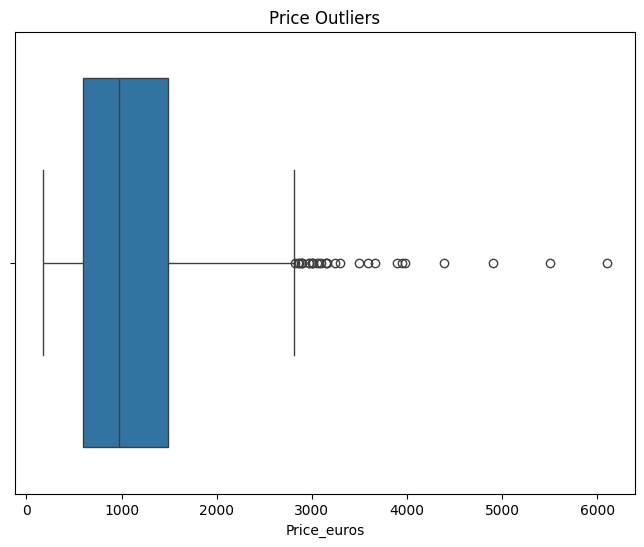

In [38]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=data["Price_euros"]
)

plt.title(
    "Price Outliers"
)

plt.show()

In [39]:
Q1 = data['Price_euros'].quantile(0.25)

Q3 = data['Price_euros'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

data = data[
    (data['Price_euros'] >= lower)
    &
    (data['Price_euros'] <= upper)
]

In [40]:
data['Ram'] = data['Ram'].str.replace(
    'GB',
    ''
)

data['Ram'] = data['Ram'].astype(int)

In [41]:
data['Weight'] = data['Weight'].str.replace(
    'kg',
    ''
)

data['Weight'] = data['Weight'].astype(float)

In [42]:
le = LabelEncoder()

columns = [
    'Company',
    'Product',
    'TypeName',
    'ScreenResolution',
    'Cpu',
    'Memory',
    'Gpu',
    'OpSys'
]

for col in columns:

    data[col] = le.fit_transform(
        data[col]
    )

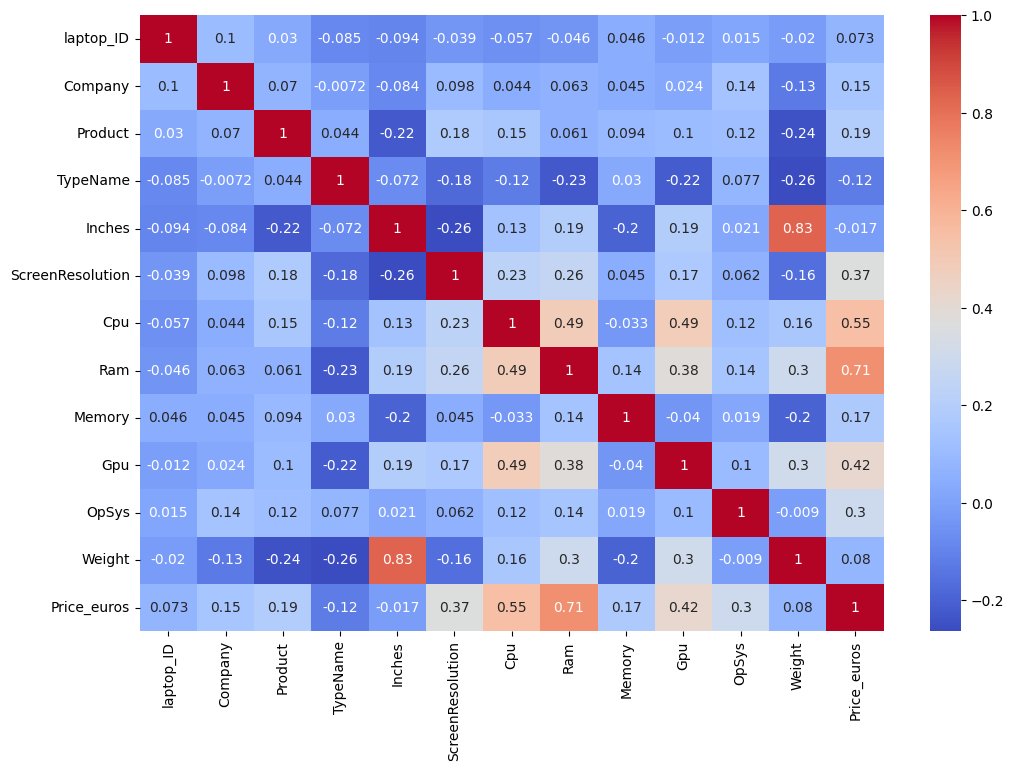

In [43]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True
)

plt.show()

In [68]:
X = data[
    [
        'Company',
        'TypeName',
        'Inches',
        'Ram',
        'OpSys',
        'Weight'
    ]
]

y = data['Price_euros']

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [70]:
lr = LinearRegression()

dt = DecisionTreeRegressor(
    random_state=42
)

rf = RandomForestRegressor(
    random_state=42
)

In [71]:
lr.fit(X_train,y_train)

LinearRegression()

In [72]:
dt.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [73]:
rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [74]:
lr_pred = lr.predict(X_test)

In [75]:
dt_pred = dt.predict(X_test)

In [76]:
rf_pred = rf.predict(X_test)

In [77]:
lr_score = r2_score(
    y_test,
    lr_pred
)

dt_score = r2_score(
    y_test,
    dt_pred
)

rf_score = r2_score(
    y_test,
    rf_pred
)

print(
    "Linear Regression:",
    lr_score
)

print(
    "Decision Tree:",
    dt_score
)

print(
    "Random Forest:",
    rf_score
)

Linear Regression: 0.6099981857082872
Decision Tree: 0.7872663479364836
Random Forest: 0.8038255303171158


In [78]:
stack_model = StackingRegressor(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('rf', rf)
    ],
    final_estimator=LinearRegression()
)

In [79]:
stack_model.fit(X_train, y_train)

StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('dt', DecisionTreeRegressor(random_state=42)),
                              ('rf', RandomForestRegressor(random_state=42))],
                  final_estimator=LinearRegression())

In [80]:
stack_pred = stack_model.predict(X_test)

In [81]:
stack_score = r2_score(y_test, stack_pred)

print("Stacking Regressor:", stack_score)

Stacking Regressor: 0.8144834579905209


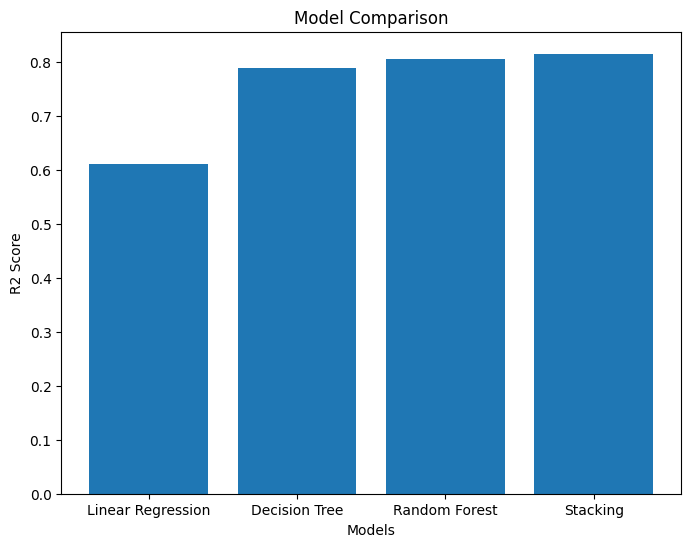

In [82]:
models = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "Stacking"
]

scores = [
    lr_score,
    dt_score,
    rf_score,
    stack_score
]

plt.figure(figsize=(8,6))

plt.bar(models, scores)

plt.xlabel("Models")

plt.ylabel("R2 Score")

plt.title("Model Comparison")

plt.show()

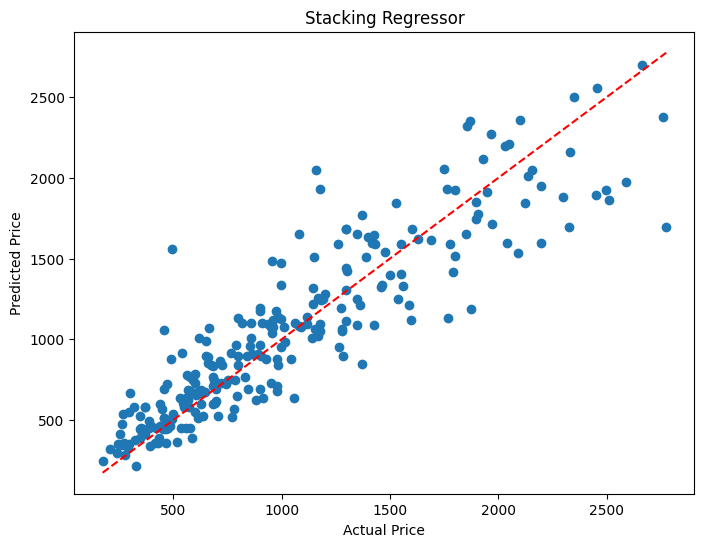

In [83]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    stack_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Stacking Regressor"
)

plt.show()

In [85]:
print("Linear Regression:", lr_score)
print("Decision Tree:", dt_score)
print("Random Forest:", rf_score)
print("Stacking Regressor:", stack_score)

Linear Regression: 0.6099981857082872
Decision Tree: 0.7872663479364836
Random Forest: 0.8038255303171158
Stacking Regressor: 0.8144834579905209


In [89]:
import joblib

joblib.dump(stack_model, "stacking_model.pkl")

['stacking_model.pkl']